# Introdução à Inteligência Artificial e Fundamentos de Python

## O Algoritmo *k*-means


O algoritmo para aprendizado de máquina  **Não supervisionado** *k*-means é um método para particionamento de dados em *k* grupos (distintos). O algoritmo tem uma relação próxima com o **KNN**, o qual pode ser aplicado em grupos de dados particionados pelo *k*-means para classificação de novos dados. O algoritmo é descrito  na imagem abaixo:

<div>
<img src="k means-Cgpt.png" width="400" height="700">   
</div>



    Fonte: Inteligência Artificial
  

In [1]:
# Importação de bibliotecas
# A biblioteca scikit-learn será usada para gerar os conjuntos de dados
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

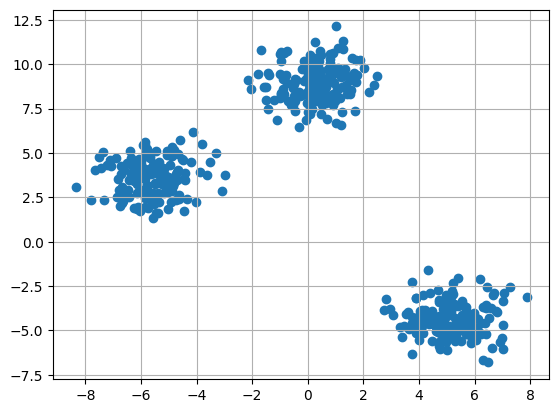

In [2]:
# geração e visualização dos conjuntos de dados
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()


Muitas vezes variáveis diferentes em conjuntos de dados diferem fortemente na escala de valores, resultando em suma situação  em que variáveis numericamente maiores influenciem mais na formação dos clusters. Imagine que os dados sejam formados por duas características, $x_1$ e $x_2$. A distância euclidiana será calculada com a expressão
$$d(\textbf{x}-\textbf{c})=\sqrt{(x_1-c_1)^2+(x_2-c_2)^2},$$
onde $c$ é o centro do *cluster*. 

Se a escala de valores de $x_2$ for muito diferente da de $x_1$, o cálculo da distância será definido pela característica de maior escala, fazendo que esta característica domine o agrupamento de dados. Para contornar este problema, devemos fazer um escalamento das coordenadas (características): 

$$ x_i=\frac{ x_i-\mu}{\sigma}$$
onde 
$\mu$ é a média da variável e $\sigma$ é seu desvio padrão. Esta operação é automaticamente realizada pelo método `StandardScaler` da biblioteca scikit-learn.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
# inicialização randômica dos centros 

k = 3 # 3 Clusters

clusters = {} # Inicialmente cria uma lista vazia para os Clusters
np.random.seed(0)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1) 
    points = [] # cada Cluster terá uma lista de pontos atribuídos, aqui inicializados com uma lista vazia
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters

{0: {'center': array([0.19525402, 0.86075747]), 'points': []},
 1: {'center': array([0.4110535 , 0.17953273]), 'points': []},
 2: {'center': array([-0.3053808 ,  0.58357645]), 'points': []}}

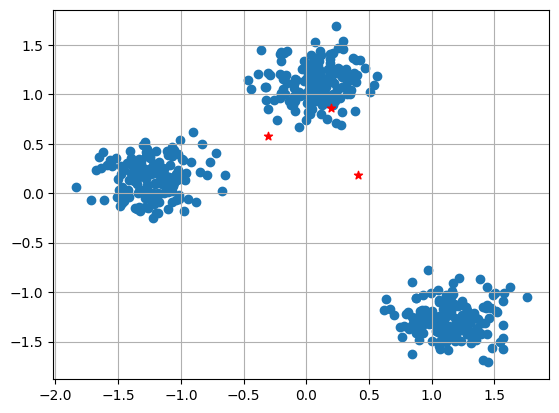

In [5]:
# Visualização dos dados com os centros iniciais

def Plot_Clusters(X,clusters):
    plt.scatter(X[:,0],X[:,1])
    plt.grid(True)
    for i in clusters:
        center = clusters[i]['center']
        plt.scatter(center[0],center[1],marker = '*',c = 'red')
    plt.show()

Plot_Clusters(X,clusters)

In [6]:
# Função para cálculo da distância euclidiana
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [7]:
# Atribuição de pontos aos Clusters
def assign_clusters(X, clusters):
    # para cada ponto...
    #--------------------
    for idx in range(X.shape[0]): 
        dist = []
        curr_x = X[idx]  
        # para cada Cluster
        #------------------
        for i in range(k): 
            # Calcula a distância do ponto ao centro do Cluster
            dis = distance(curr_x,clusters[i]['center']) 
            
            # adiciona a distância à lista contendo as distâncias aos centros dos Clusters
            dist.append(dis)
            
        # Escolhe o Cluster mais próximo
        curr_cluster = np.argmin(dist) 
        
        # Atribui o ponto ao Cluster mais próximo
        clusters[curr_cluster]['points'].append(idx) 
    return clusters


In [8]:
# Atualização dos centroides dos Clusters
def update_clusters(X, clusters):
    # para cada Cluster....
    #----------------------
    for i in range(k):
        # Recupera os índices dos pontos do Cluster
        indices = clusters[i]['points'] 
        
        # Se o Cluster tem ao menos um ponto, determina o novo centro como a média das coordenadas dos pontos 
        if len(indices) > 0:
            
            # Recupera os pontos originais
            points = X[indices]   
            
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center

            # Limpa a lista de pontos do Cluster para a próxima iteração
            clusters[i]['points'] = []
    return clusters

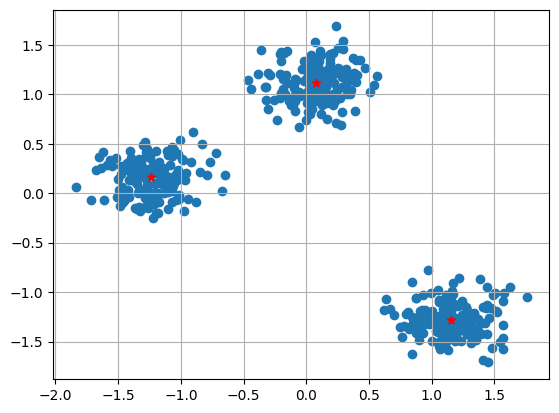

In [9]:
# Atualização iterativa dos centros dos Clusters e seus pontos atribuídos
max_iters = 100

for _ in range(max_iters):

    # recupera os centros atuais dos Clusters
    old_centers = [clusters[i]['center'].copy() for i in range(k)]

    # Atribui pontos aos Clusters
    clusters = assign_clusters(X, clusters)

    # Atualiza os centroides
    clusters = update_clusters(X, clusters)

    # recupera os novos centros e compara com os antigos
    new_centers = [clusters[i]['center'] for i in range(k)]
    if np.allclose(old_centers, new_centers):
        # Atribui pontos aos Clusters
        clusters = assign_clusters(X, clusters)
        break

Plot_Clusters(X,clusters)

Predição das classes de cada ponto:

In [10]:
def pred_cluster (X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [11]:
pred=pred_cluster(X,clusters)

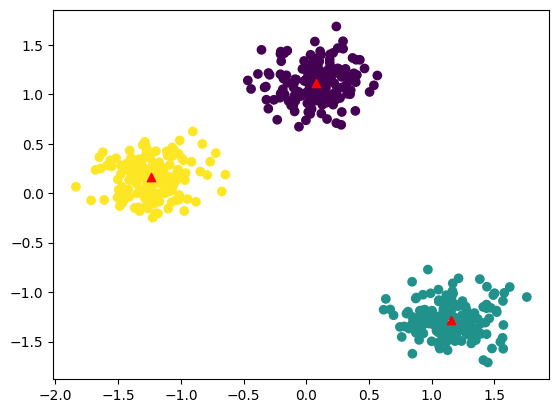

In [12]:
# Visualização dos pontos coloridos segundo suas classes
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

### Aplicação Prática: o conjunto de dados Íris (Liscença BSD)

Este conjunto de dados contém 150 amostras de flores Íris que pertencem a uma de três espécies, Íris setosa, Íris versicolor ou Íris virginica. Para classificação binária apenas os dois primeiros tipos (setosa e versicolor) serão usados, e também apenas as duas primeiras características de cada flor (largura e comprimento da sépala). Seguiremos os mesmo procedimentos que os usados no exemplo anterior. 

In [13]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data[:, :2]
y = iris.target       # 0=setosa,1=versivolor e 2=virginica
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [15]:
# seleciona flores setosa e versicolor
X = X[(y == 0) | (y == 1)] # apenas dados cuja classe seja setosa ou versicolor
y = y[(y == 0) | (y == 1)] # apenas os rótulos dessas duas classes

In [16]:
# padronização das variaveis
scaler = StandardScaler()
X = scaler.fit_transform(X)

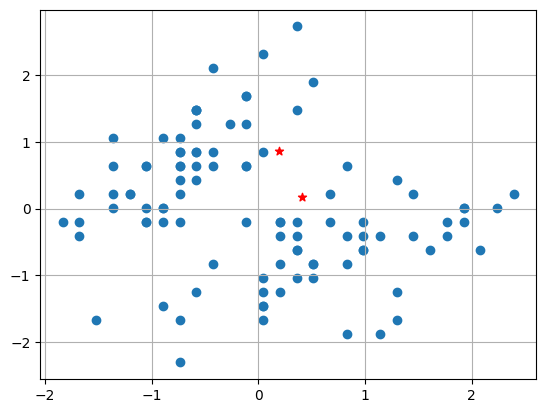

In [17]:
# inicialização randômica dos centros 
k = 2 # 2 Clusters

clusters = {} # Inicialmente cria uma lista vazia para os Clusters
np.random.seed(0)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1) 
    points = [] # cada Cluster terá uma lista de pontos atribuídos, aqui inicializados com uma lista vazia
    cluster = {
        'center' : center,
        'points' : []
    }
    
    clusters[idx] = cluster
    
clusters
Plot_Clusters(X,clusters)

In [18]:
max_iters = 1000

for _ in range(max_iters):

    # recupera os centros atuais dos Clusters
    old_centers = [clusters[i]['center'].copy() for i in range(k)]

    # Atribui pontos aos Clusters
    clusters = assign_clusters(X, clusters)

    # Atualiza os centroides
    clusters = update_clusters(X, clusters)

    # recupera os novos centros e compara com os antigos
    new_centers = [clusters[i]['center'] for i in range(k)]
    if np.allclose(old_centers, new_centers):
        # Atribui pontos aos Clusters
        clusters = assign_clusters(X, clusters)
        break


In [19]:
# contagem do número final de cada tipo de íris em cada grupo, cálculo do mais comum.
from collections import Counter

pred=pred_cluster(X,clusters)
 
classe=[]
for i in range(k):
    indices = clusters[i]['points']
    classes = y[indices] 
    contagem = Counter(classes)
    print(f'\nCluster {i}')
    for cl, quantidade in contagem.items():
        print(
            iris.target_names[cl],
            ':',
            quantidade
        )
    print(contagem)
    print(contagem.most_common(1)[0][0])
    print(iris.target_names[contagem.most_common(1)[0][0]])
    classe.append(contagem.most_common(1)[0][0])


Cluster 0
setosa : 49
Counter({0: 49})
0
setosa

Cluster 1
setosa : 1
versicolor : 50
Counter({1: 50, 0: 1})
1
versicolor


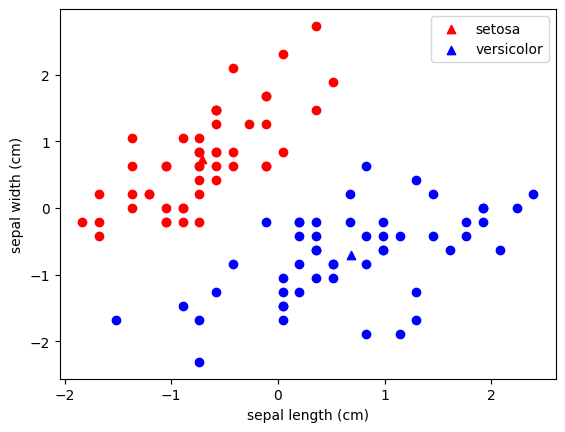

In [20]:
#plt.scatter(X[:,0],X[:,1],c = pred)

colors=['red', 'blue']
for i in clusters:
    idx = clusters[i]['points']
    Xpoints=X[idx]
    plt.scatter(Xpoints[:,0],Xpoints[:,1],c=colors[i])
    center = clusters[i]['center']
    
    plt.scatter(center[0],center[1],marker = '^',c = colors[i],label=iris.target_names[classe[i]])
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.legend()
plt.show()